In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
img_edges_bgr = cv2.imread('lab2_1.jpg')
img_blend_bgr = cv2.imread('lab2_2.jpg')
img_color_bgr = cv2.imread('lab2_3.jpg')
img_edges_rgb = cv2.cvtColor(img_edges_bgr, cv2.COLOR_BGR2RGB)
img_blend_rgb = cv2.cvtColor(img_blend_bgr, cv2.COLOR_BGR2RGB)
img_color_rgb = cv2.cvtColor(img_color_bgr, cv2.COLOR_BGR2RGB)
img1_rgb = img_edges_rgb
img2_rgb = img_blend_rgb
img3_rgb = img_color_rgb


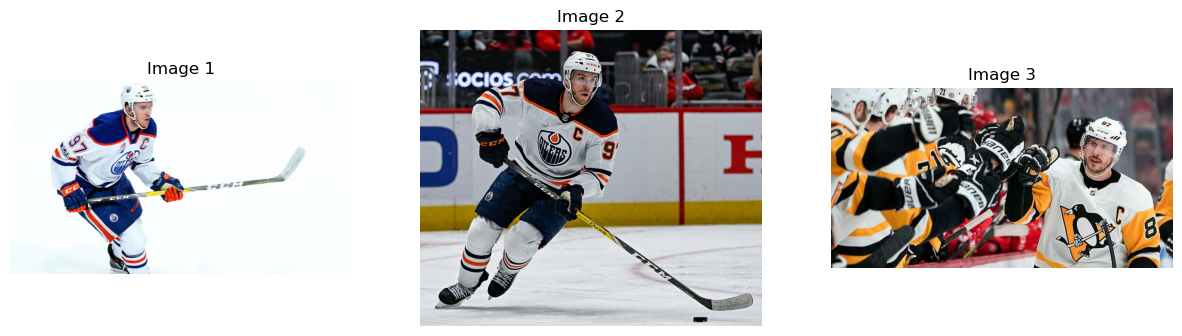

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_edges_rgb)
plt.title('Image 1')
_ = plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(img_blend_rgb)
plt.title('Image 2')
_ = plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(img_color_rgb)
plt.title('Image 3')
_ = plt.axis('off')
img1_rgb_small = cv2.resize(img1_rgb, (360, 200))
img1_gray_small = cv2.cvtColor(img1_rgb_small, cv2.COLOR_RGB2GRAY)


In [ ]:
def rgb_to_hsv_numpy(img_rgb):
    img = img_rgb.astype(np.float32) / 255.0
    r, g, b = img[..., 0], img[..., 1], img[..., 2]
    cmax = np.max(img, axis=2)
    cmin = np.min(img, axis=2)
    delta = cmax - cmin
    h = np.zeros_like(cmax)
    s = np.zeros_like(cmax)
    v = cmax.copy()
    mask = delta > 1e-8
    r_is_max = (cmax == r) & mask
    g_is_max = (cmax == g) & mask
    b_is_max = (cmax == b) & mask
    h[r_is_max] = ((g[r_is_max] - b[r_is_max]) / delta[r_is_max]) % 6
    h[g_is_max] = ((b[g_is_max] - r[g_is_max]) / delta[g_is_max]) + 2
    h[b_is_max] = ((r[b_is_max] - g[b_is_max]) / delta[b_is_max]) + 4
    h = h * 60.0
    s[cmax > 1e-8] = delta[cmax > 1e-8] / cmax[cmax > 1e-8]
    hsv = np.stack([h / 2.0, s * 255.0, v * 255.0], axis=2)
    return np.clip(hsv, 0, 255).astype(np.uint8)
def rgb_to_hsl_numpy(img_rgb):
    img = img_rgb.astype(np.float32) / 255.0
    r, g, b = img[..., 0], img[..., 1], img[..., 2]
    cmax = np.max(img, axis=2)
    cmin = np.min(img, axis=2)
    delta = cmax - cmin
    l = (cmax + cmin) / 2.0
    h = np.zeros_like(l)
    s = np.zeros_like(l)
    mask = delta > 1e-8
    r_is_max = (cmax == r) & mask
    g_is_max = (cmax == g) & mask
    b_is_max = (cmax == b) & mask
    h[r_is_max] = ((g[r_is_max] - b[r_is_max]) / delta[r_is_max]) % 6
    h[g_is_max] = ((b[g_is_max] - r[g_is_max]) / delta[g_is_max]) + 2
    h[b_is_max] = ((r[b_is_max] - g[b_is_max]) / delta[b_is_max]) + 4
    h = h * 60.0
    denom = 1.0 - np.abs(2.0 * l - 1.0)
    valid = mask & (denom > 1e-8)
    s[valid] = delta[valid] / denom[valid]
    hsl = np.stack([h / 2.0, l * 255.0, s * 255.0], axis=2)
    return np.clip(hsl, 0, 255).astype(np.uint8)


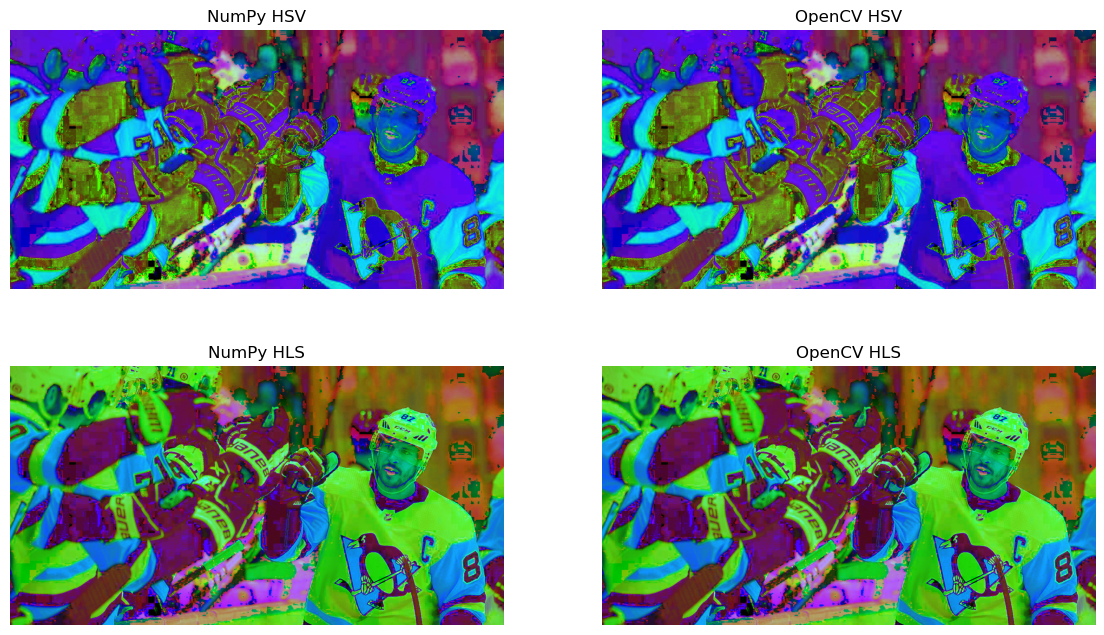

In [ ]:
# RGB -> HSV и RGB -> HLS
hsv_np = rgb_to_hsv_numpy(img3_rgb)
hsv_cv = cv2.cvtColor(img3_rgb, cv2.COLOR_RGB2HSV)
hls_np = rgb_to_hsl_numpy(img3_rgb)
hls_cv = cv2.cvtColor(img3_rgb, cv2.COLOR_RGB2HLS)
plt.figure(figsize=(14, 8))
plt.subplot(2, 2, 1)
plt.imshow(hsv_np)
plt.title('NumPy HSV')
_ = plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(hsv_cv)
plt.title('OpenCV HSV')
_ = plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(hls_np)
plt.title('NumPy HLS')
_ = plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(hls_cv)
plt.title('OpenCV HLS')
_ = plt.axis('off')


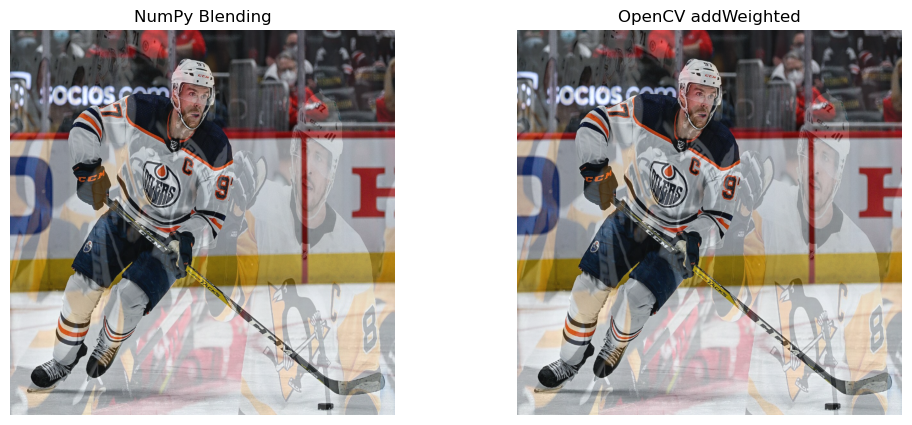

In [ ]:
# blending 
def blend_numpy(img_a, img_b, alpha=0.7, beta=0.3, gamma=0.0):
    a = img_a.astype(np.float32)
    b = img_b.astype(np.float32)
    out = alpha * a + beta * b + gamma
    return np.clip(out, 0, 255).astype(np.uint8)

h, w = 700, 700
blend_a = cv2.resize(img2_rgb, (w, h))
blend_b = cv2.resize(img3_rgb, (w, h))

alpha, beta, gamma = 0.75, 0.25, 10
blend_np = blend_numpy(blend_a, blend_b, alpha, beta, gamma)
blend_cv = cv2.addWeighted(blend_a, alpha, blend_b, beta, gamma)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(blend_np)
plt.title('NumPy Blending')
_ = plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blend_cv)
plt.title('OpenCV addWeighted')
_ = plt.axis('off')


In [ ]:
def threshold_binary_numpy(gray, thresh, maxval=255):
    return np.where(gray > thresh, maxval, 0).astype(np.uint8)
def threshold_binary_inv_numpy(gray, thresh, maxval=255):
    return np.where(gray > thresh, 0, maxval).astype(np.uint8)
def threshold_tozero_numpy(gray, thresh):
    return np.where(gray > thresh, gray, 0).astype(np.uint8)
def threshold_tozero_inv_numpy(gray, thresh):
    return np.where(gray > thresh, 0, gray).astype(np.uint8)
def threshold_trunc_numpy(gray, thresh):
    return np.where(gray > thresh, thresh, gray).astype(np.uint8)


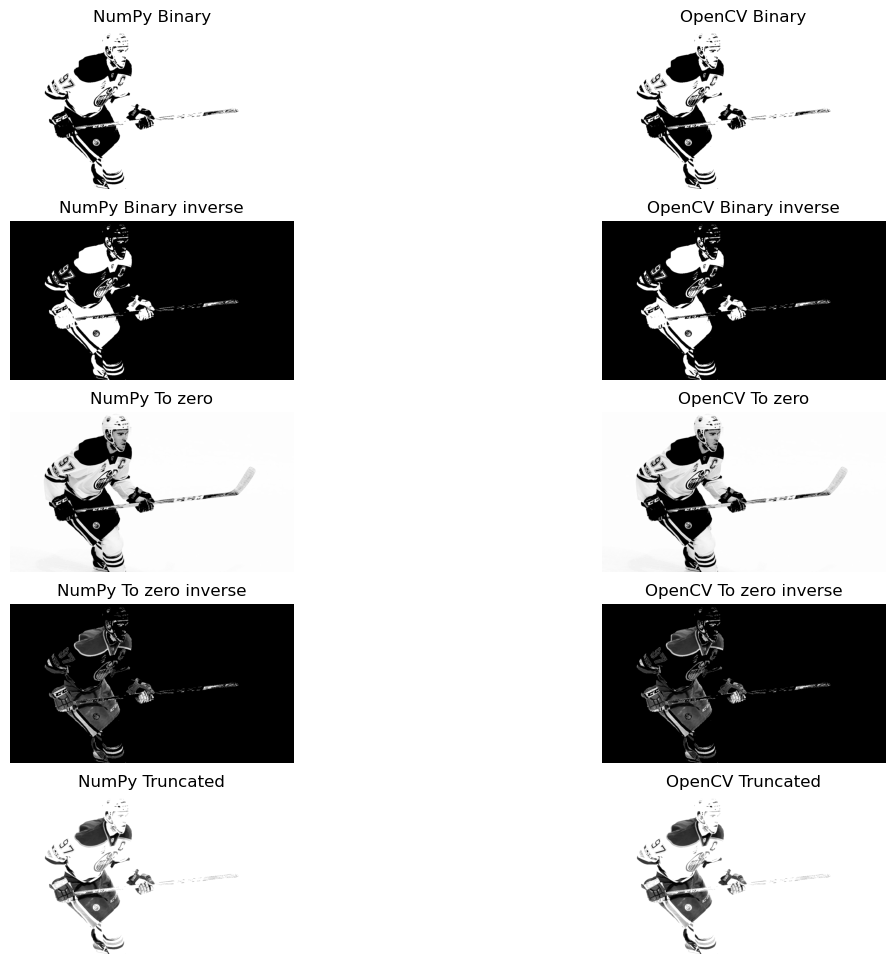

In [ ]:
# пороговые режимы
img_gray = cv2.cvtColor(img1_rgb, cv2.COLOR_RGB2GRAY)
T = 120
b_np = threshold_binary_numpy(img_gray, T)
bi_np = threshold_binary_inv_numpy(img_gray, T)
tz_np = threshold_tozero_numpy(img_gray, T)
tzi_np = threshold_tozero_inv_numpy(img_gray, T)
tr_np = threshold_trunc_numpy(img_gray, T)
_, b_cv = cv2.threshold(img_gray, T, 255, cv2.THRESH_BINARY)
_, bi_cv = cv2.threshold(img_gray, T, 255, cv2.THRESH_BINARY_INV)
_, tz_cv = cv2.threshold(img_gray, T, 255, cv2.THRESH_TOZERO)
_, tzi_cv = cv2.threshold(img_gray, T, 255, cv2.THRESH_TOZERO_INV)
_, tr_cv = cv2.threshold(img_gray, T, 255, cv2.THRESH_TRUNC)
pairs = [
    ('Binary', b_np, b_cv),
    ('Binary inverse', bi_np, bi_cv),
    ('To zero', tz_np, tz_cv),
    ('To zero inverse', tzi_np, tzi_cv),
    ('Truncated', tr_np, tr_cv),
]
plt.figure(figsize=(14, 12))
for i, (name, n, c) in enumerate(pairs, 1):
    plt.subplot(5, 2, 2 * i - 1)
    plt.imshow(n, cmap='gray')
    plt.title(f'NumPy {name}')
    _ = plt.axis('off')
    plt.subplot(5, 2, 2 * i)
    plt.imshow(c, cmap='gray')
    plt.title(f'OpenCV {name}')
    _ = plt.axis('off')


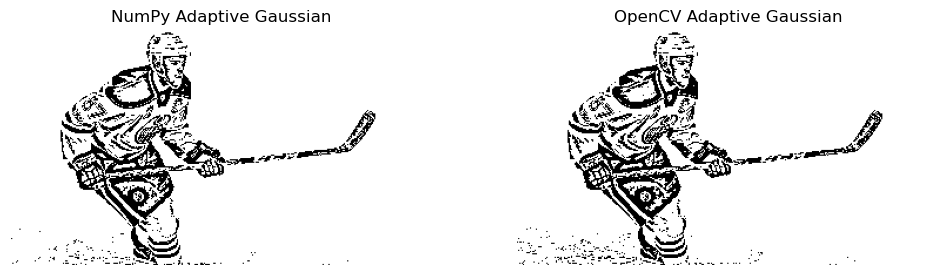

In [ ]:
# гауссовская адаптивная пороговая обработка
def gaussian_kernel(size=11, sigma=2.0):
    if size % 2 == 0:
        raise ValueError('size должен быть нечётным')
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel.astype(np.float32)
def conv2d_gray_numpy(img_gray, kernel):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img_gray.astype(np.float32), ((ph, ph), (pw, pw)), mode='reflect')
    out = np.zeros_like(img_gray, dtype=np.float32)
    for y in range(img_gray.shape[0]):
        for x in range(img_gray.shape[1]):
            roi = padded[y:y + kh, x:x + kw]
            out[y, x] = np.sum(roi * kernel)
    return out
def adaptive_threshold_gaussian_numpy(gray, block_size=11, C=2):
    kernel = gaussian_kernel(size=block_size, sigma=block_size / 6)
    local = conv2d_gray_numpy(gray, kernel)
    return np.where(gray.astype(np.float32) > (local - C), 255, 0).astype(np.uint8)
adapt_np = adaptive_threshold_gaussian_numpy(img1_gray_small, block_size=11, C=2)
adapt_cv = cv2.adaptiveThreshold(
    img1_gray_small, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(adapt_np, cmap='gray')
plt.title('NumPy Adaptive Gaussian')
_ = plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(adapt_cv, cmap='gray')
plt.title('OpenCV Adaptive Gaussian')
_ = plt.axis('off')


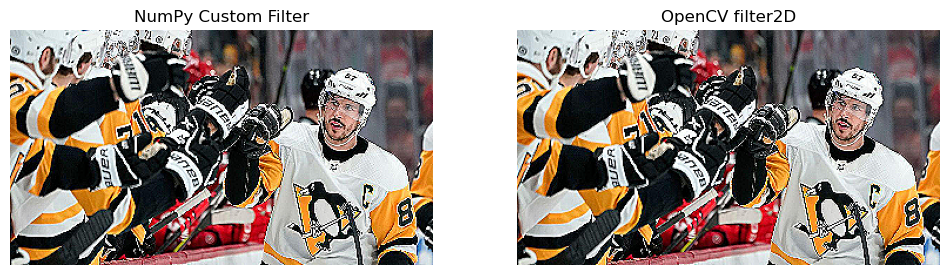

In [ ]:
# свой фильтр (через свёртку) и OpenCV filter2D
def conv2d_color_numpy(img_rgb, kernel):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img_rgb.astype(np.float32), ((ph, ph), (pw, pw), (0, 0)), mode='reflect')
    out = np.zeros_like(img_rgb, dtype=np.float32)
    for y in range(img_rgb.shape[0]):
        for x in range(img_rgb.shape[1]):
            roi = padded[y:y + kh, x:x + kw, :]
            out[y, x, :] = np.sum(roi * kernel[:, :, None], axis=(0, 1))
    return np.clip(out, 0, 255).astype(np.uint8)
custom_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)
filtered_np = conv2d_color_numpy(cv2.resize(img3_rgb, (360, 200)), custom_kernel)
filtered_cv = cv2.filter2D(cv2.resize(img3_rgb, (360, 200)), -1, custom_kernel)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(filtered_np)
plt.title('NumPy Custom Filter')
_ = plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(filtered_cv)
plt.title('OpenCV filter2D')
_ = plt.axis('off')


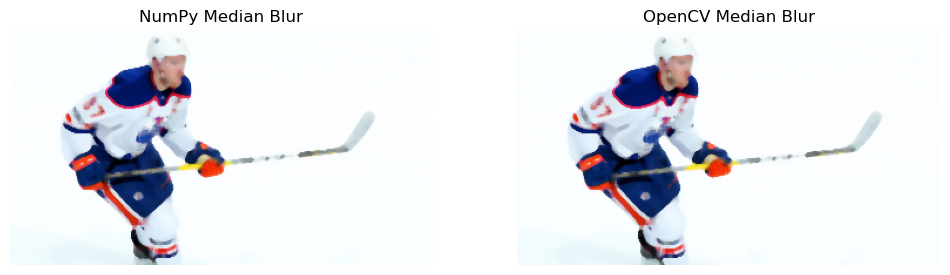

In [ ]:
# медианное размытие
def median_blur_numpy(img_rgb, ksize=5):
    if ksize % 2 == 0:
        raise ValueError('ksize должен быть нечётным')
    p = ksize // 2
    padded = np.pad(img_rgb, ((p, p), (p, p), (0, 0)), mode='reflect')
    out = np.zeros_like(img_rgb)
    for y in range(img_rgb.shape[0]):
        for x in range(img_rgb.shape[1]):
            roi = padded[y:y + ksize, x:x + ksize, :]
            out[y, x, :] = np.median(roi, axis=(0, 1))
    return out.astype(np.uint8)

small_rgb = img1_rgb_small.copy()
med_np = median_blur_numpy(small_rgb, ksize=5)
med_cv = cv2.medianBlur(small_rgb, 5)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(med_np)
plt.title('NumPy Median Blur')
_ = plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(med_cv)
plt.title('OpenCV Median Blur')
_ = plt.axis('off')


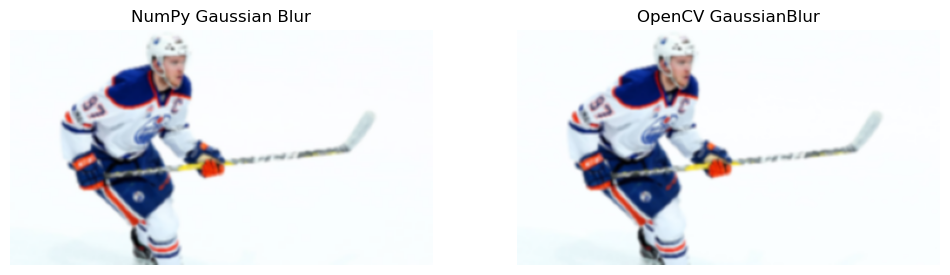

In [ ]:
# гауссовское размытие
def gaussian_blur_numpy(img_rgb, ksize=5, sigma=1.2):
    kernel = gaussian_kernel(size=ksize, sigma=sigma)
    return conv2d_color_numpy(img_rgb, kernel)
gauss_np = gaussian_blur_numpy(small_rgb, ksize=5, sigma=1.2)
gauss_cv = cv2.GaussianBlur(small_rgb, (5, 5), 1.2)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(gauss_np)
plt.title('NumPy Gaussian Blur')
_ = plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(gauss_cv)
plt.title('OpenCV GaussianBlur')
_ = plt.axis('off')


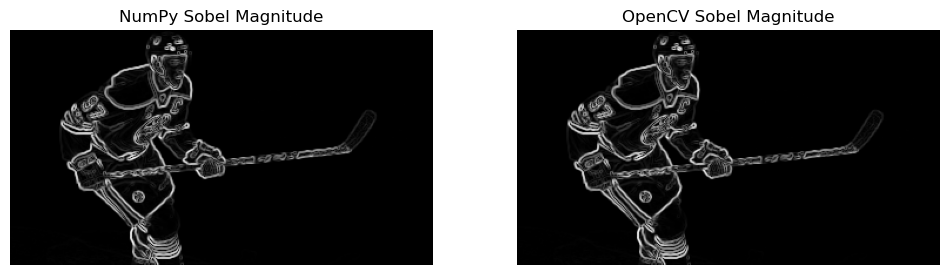

In [ ]:
# фильтр Собеля
def sobel_numpy(gray):
    kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    gx = conv2d_gray_numpy(gray, kx)
    gy = conv2d_gray_numpy(gray, ky)
    mag = np.sqrt(gx**2 + gy**2)
    mag = (mag / (mag.max() + 1e-8) * 255).astype(np.uint8)
    return mag
small_gray = cv2.cvtColor(small_rgb, cv2.COLOR_RGB2GRAY)
sobel_np = sobel_numpy(small_gray)
sx = cv2.Sobel(small_gray, cv2.CV_32F, 1, 0, ksize=3)
sy = cv2.Sobel(small_gray, cv2.CV_32F, 0, 1, ksize=3)
sobel_cv = np.sqrt(sx**2 + sy**2)
sobel_cv = (sobel_cv / (sobel_cv.max() + 1e-8) * 255).astype(np.uint8)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(sobel_np, cmap='gray')
plt.title('NumPy Sobel Magnitude')
_ = plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(sobel_cv, cmap='gray')
plt.title('OpenCV Sobel Magnitude')
_ = plt.axis('off')


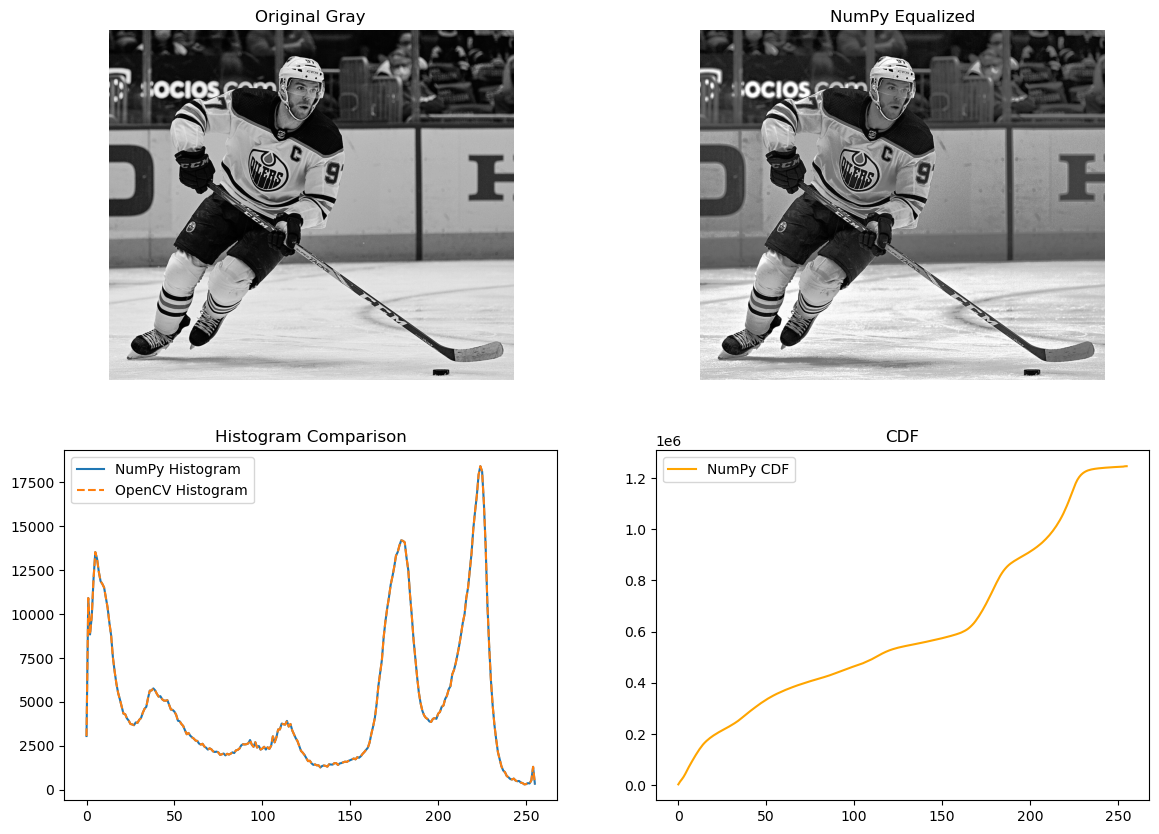

In [ ]:
def histogram_numpy(gray):
    hist = np.zeros(256, dtype=np.int64)
    vals, counts = np.unique(gray, return_counts=True)
    hist[vals] = counts
    return hist


def equalize_hist_numpy(gray):
    hist = histogram_numpy(gray)
    cdf = hist.cumsum()

    cdf_nonzero = cdf[cdf > 0]
    cdf_min = cdf_nonzero.min()
    cdf_max = cdf_nonzero.max()

    lut = np.round((cdf - cdf_min) / (cdf_max - cdf_min + 1e-8) * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    eq = lut[gray]
    return eq, hist, cdf

img_eq_gray = cv2.cvtColor(img2_rgb, cv2.COLOR_RGB2GRAY)

eq_np, hist_np, cdf_np = equalize_hist_numpy(img_eq_gray)
eq_cv = cv2.equalizeHist(img_eq_gray)
hist_cv = cv2.calcHist([img_eq_gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_eq_gray, cmap='gray')
plt.title('Original Gray')
_ = plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(eq_np, cmap='gray')
plt.title('NumPy Equalized')
_ = plt.axis('off')

plt.subplot(2, 2, 3)
plt.plot(hist_np, label='NumPy Histogram')
plt.plot(hist_cv, '--', label='OpenCV Histogram')
plt.title('Histogram Comparison')
_ = plt.legend()

plt.subplot(2, 2, 4)
plt.plot(cdf_np, color='orange', label='NumPy CDF')
plt.title('CDF')
_ = plt.legend()


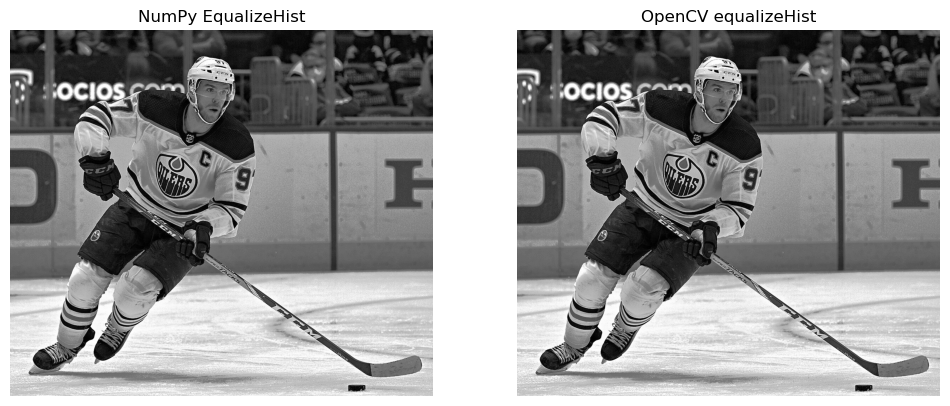

In [ ]:
# эквализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(eq_np, cmap='gray')
plt.title('NumPy EqualizeHist')
_ = plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(eq_cv, cmap='gray')
plt.title('OpenCV equalizeHist')
_ = plt.axis('off')
